# EDA - Análisis después de la limpieza
Validar que la limpieza funcionó correctamente y que los datos limpios estan listos para feature engineering. De los siguientes datasets:
- dataset_cleaned_padron.parquet
- dataset_cleaned_renta.parquet
- dataset_cleaned_precios.parquet
- dataset_cleaned_barrios.parquet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup config
current_dir = Path.cwd()
for parent in current_dir.parents:
    if (parent / "config.py").exists():
        sys.path.insert(0, str(parent))
        break

from config import PROCESSED_PATHS



# Padrón municipal

### Validaciones básicas

In [3]:
df_padron = pd.read_parquet(PROCESSED_PATHS['cleaned_padron'])

print(f"Padrón limpio cargado: {len(df_padron):,} filas × {df_padron.shape[1]} columnas\n")

nulos = df_padron.isnull().sum().sum()
duplicados = df_padron.duplicated().sum()
tamaño = df_padron.memory_usage(deep=True).sum() / 1e6

print(f"- Nulos totales: {nulos}")
print(f"- Duplicados: {duplicados}")
print(f"- Tamaño: {tamaño:.2f} MB")
print(f"- Tipos: {df_padron.dtypes.value_counts().to_dict()}")

print("\n Estructura:")
df_padron.head()

Padrón limpio cargado: 241,124 filas × 12 columnas

- Nulos totales: 0
- Duplicados: 0
- Tamaño: 35.21 MB
- Tipos: {dtype('int64'): 9, <StringDtype(na_value=nan)>: 3}

 Estructura:


,COD_DISTRITO,DESC_DISTRITO,COD_DIST_BARRIO,DESC_BARRIO,COD_BARRIO,COD_DIST_SECCION,COD_SECCION,COD_EDAD_INT,ESPANOLESHOMBRES,ESPANOLESMUJERES,EXTRANJEROSHOMBRES,EXTRANJEROSMUJERES
0,2,ARGANZUELA,202,ACACIAS,2,2019,19,81,3,9,0,0
1,8,FUENCARRAL-EL PARDO,805,LA PAZ,5,8098,98,74,11,10,0,0
2,1,CENTRO,105,UNIVERSIDAD,5,1092,92,81,2,3,1,0
3,2,ARGANZUELA,201,IMPERIAL,1,2009,9,92,2,7,0,0
4,5,CHAMARTIN,505,NUEVA ESPAÑA,5,5084,84,74,9,9,1,0


### Cobertura Geográfica

In [4]:
distritos = df_padron['DESC_DISTRITO'].nunique()
barrios = df_padron['DESC_BARRIO'].nunique()
edades = df_padron['COD_EDAD_INT'].nunique()

print(f"- Distritos: {distritos}")
print(f"- Barrios: {barrios}")
print(f"- Rangos de edad: {edades}")

# Población por distrito (top 15)
print("\n Población por distrito (top 15):")
pop_distrito = df_padron.groupby('DESC_DISTRITO')[['ESPANOLESHOMBRES', 'ESPANOLESMUJERES', 
                                                      'EXTRANJEROSHOMBRES', 'EXTRANJEROSMUJERES']].sum()
pop_distrito['TOTAL'] = pop_distrito.sum(axis=1)
pop_distrito = pop_distrito.sort_values('TOTAL', ascending=False)
print(pop_distrito[['TOTAL']].head(15))

- Distritos: 21
- Barrios: 131
- Rangos de edad: 101

 Población por distrito (top 15):
                       TOTAL
DESC_DISTRITO               
CARABANCHEL           279925
PUENTE DE VALLECAS    259136
FUENCARRAL-EL PARDO   257272
LATINA                252646
CIUDAD LINEAL         230270
HORTALEZA             210719
VILLAVERDE            174376
SAN BLAS-CANILLEJAS   169635
TETUAN                168965
ARGANZUELA            159649
USERA                 153887
CHAMARTIN             148426
SALAMANCA             146462
CENTRO                141202
CHAMBERI              140971


### Análisis de población

In [8]:
# Totales por nacionalidad y sexo
espanoles_h = df_padron['ESPANOLESHOMBRES'].sum()
espanoles_m = df_padron['ESPANOLESMUJERES'].sum()
extranjeros_h = df_padron['EXTRANJEROSHOMBRES'].sum()
extranjeros_m = df_padron['EXTRANJEROSMUJERES'].sum()

total_espanoles = espanoles_h + espanoles_m
total_extranjeros = extranjeros_h + extranjeros_m
total_general = total_espanoles + total_extranjeros

pct_espanoles = (total_espanoles / total_general) * 100
pct_extranjeros = (total_extranjeros / total_general) * 100

print(f" POBLACIÓN TOTAL: {total_general:,}\n")

print(f"Españoles: {total_espanoles:,} ({pct_espanoles:.1f}%)")
print(f"  Hombres: {espanoles_h:,}")
print(f"  Mujeres: {espanoles_m:,}")
print(f"  Ratio H/M: {espanoles_h/espanoles_m:.3f}\n")

print(f"Extranjeros: {total_extranjeros:,} ({pct_extranjeros:.1f}%)")
print(f"  Hombres: {extranjeros_h:,}")
print(f"  Mujeres: {extranjeros_m:,}")
print(f"  Ratio H/M: {extranjeros_h/extranjeros_m:.3f}\n")

total_h = espanoles_h + extranjeros_h
total_m = espanoles_m + extranjeros_m
print(f"Ratio general H/M: {total_h/total_m:.3f}")

 POBLACIÓN TOTAL: 3,512,849

Españoles: 2,823,086 (80.4%)
  Hombres: 1,317,504
  Mujeres: 1,505,582
  Ratio H/M: 0.875

Extranjeros: 689,763 (19.6%)
  Hombres: 332,558
  Mujeres: 357,205
  Ratio H/M: 0.931

Ratio general H/M: 0.886


### Análisis de Extranjería por districto

In [9]:
# Calcular porcentaje extranjeros por distrito
df_ext = df_padron.groupby('DESC_DISTRITO')[['ESPANOLESHOMBRES', 'ESPANOLESMUJERES',
                                                'EXTRANJEROSHOMBRES', 'EXTRANJEROSMUJERES']].sum()
df_ext['ESPAÑOLES'] = df_ext['ESPANOLESHOMBRES'] + df_ext['ESPANOLESMUJERES']
df_ext['EXTRANJEROS'] = df_ext['EXTRANJEROSHOMBRES'] + df_ext['EXTRANJEROSMUJERES']
df_ext['TOTAL'] = df_ext['ESPAÑOLES'] + df_ext['EXTRANJEROS']
df_ext['PCT_EXTRANJEROS'] = (df_ext['EXTRANJEROS'] / df_ext['TOTAL']) * 100
df_ext = df_ext.sort_values('PCT_EXTRANJEROS', ascending=False)

print(" Distritos con MÁS extranjeros:")
print(df_ext[['EXTRANJEROS', 'PCT_EXTRANJEROS']].head(10))

print("\n Distritos con MENOS extranjeros:")
print(df_ext[['EXTRANJEROS', 'PCT_EXTRANJEROS']].tail(10))

 Distritos con MÁS extranjeros:
                      EXTRANJEROS  PCT_EXTRANJEROS
DESC_DISTRITO                                     
CENTRO                      43891            31.08
USERA                       44282            28.78
VILLAVERDE                  47567            27.28
CARABANCHEL                 72917            26.05
PUENTE DE VALLECAS          66677            25.73
TETUAN                      41270            24.43
LATINA                      53894            21.33
SALAMANCA                   28008            19.12
SAN BLAS-CANILLEJAS         32119            18.93
CIUDAD LINEAL               43286            18.80

 Distritos con MENOS extranjeros:
                      EXTRANJEROS  PCT_EXTRANJEROS
DESC_DISTRITO                                     
CHAMBERI                    23913            16.96
VICALVARO                   15751            15.91
HORTALEZA                   30196            14.33
ARGANZUELA                  22492            14.09
MONCLOA-ARAVACA

### Gráficos Padrón

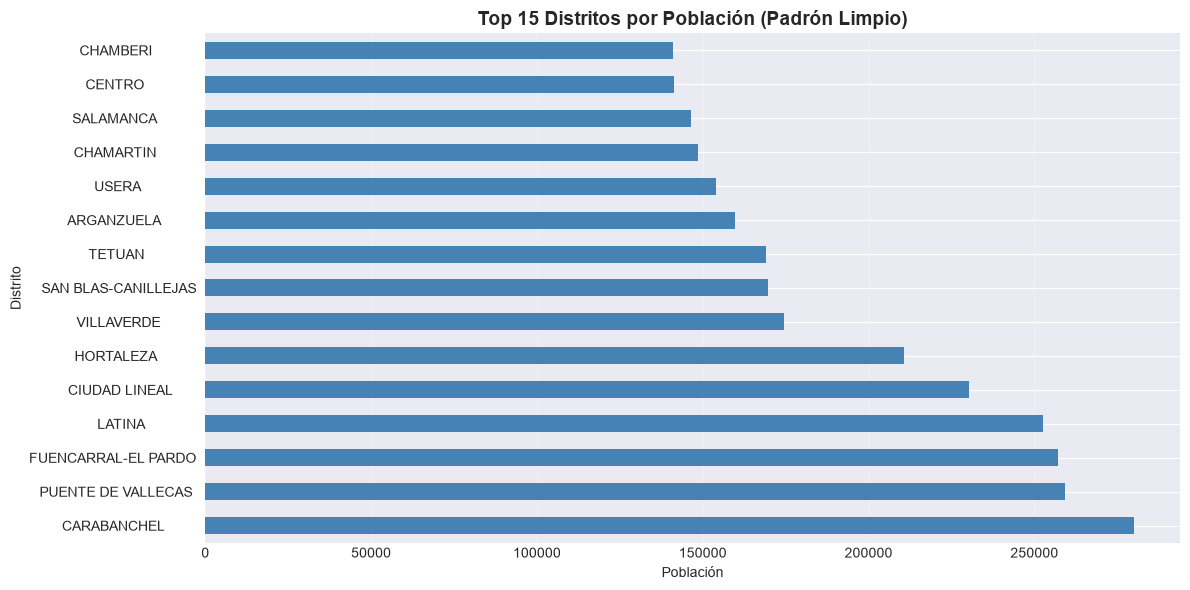

In [7]:
# Gráfico 1: Población por distrito (top 15)
fig, ax = plt.subplots(figsize=(12, 6))
pop_top = pop_distrito.head(15)['TOTAL']
pop_top.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Población')
ax.set_ylabel('Distrito')
ax.set_title('Top 15 Distritos por Población (Padrón Limpio)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

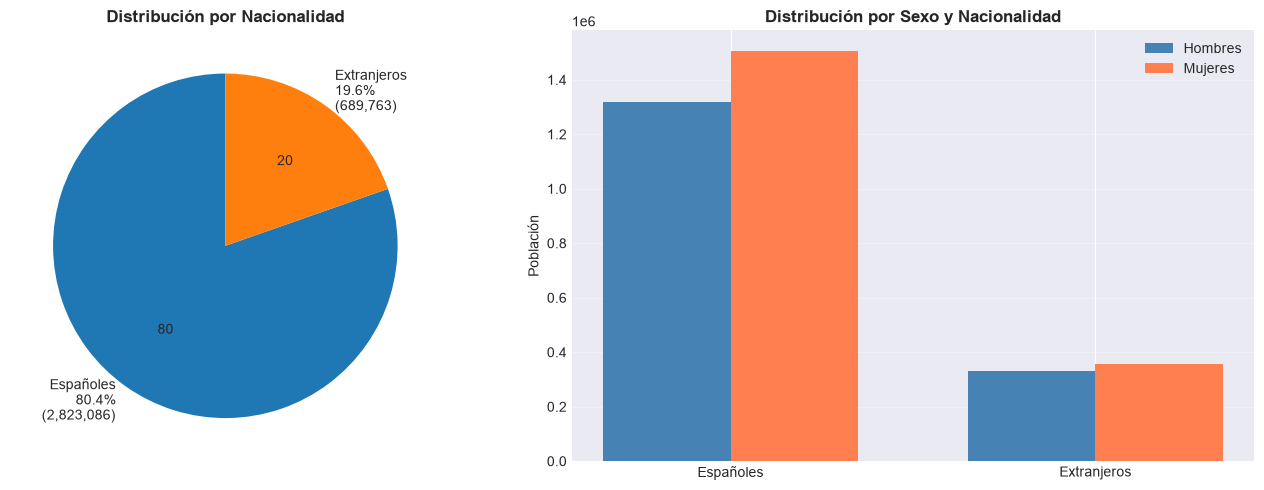

In [10]:
# Gráfico 2: Españoles vs Extranjeros
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
sizes = [total_espanoles, total_extranjeros]
labels = [f'Españoles\n{pct_espanoles:.1f}%\n({total_espanoles:,})', 
          f'Extranjeros\n{pct_extranjeros:.1f}%\n({total_extranjeros:,})']
colors = ['#1f77b4', '#ff7f0e']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.0f', startangle=90)
ax1.set_title('Distribución por Nacionalidad', fontsize=12, fontweight='bold')

# Barplot sexo
categories = ['Españoles', 'Extranjeros']
hombres = [espanoles_h, extranjeros_h]
mujeres = [espanoles_m, extranjeros_m]
x = np.arange(len(categories))
width = 0.35
ax2.bar(x - width/2, hombres, width, label='Hombres', color='steelblue')
ax2.bar(x + width/2, mujeres, width, label='Mujeres', color='coral')
ax2.set_ylabel('Población')
ax2.set_title('Distribución por Sexo y Nacionalidad', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

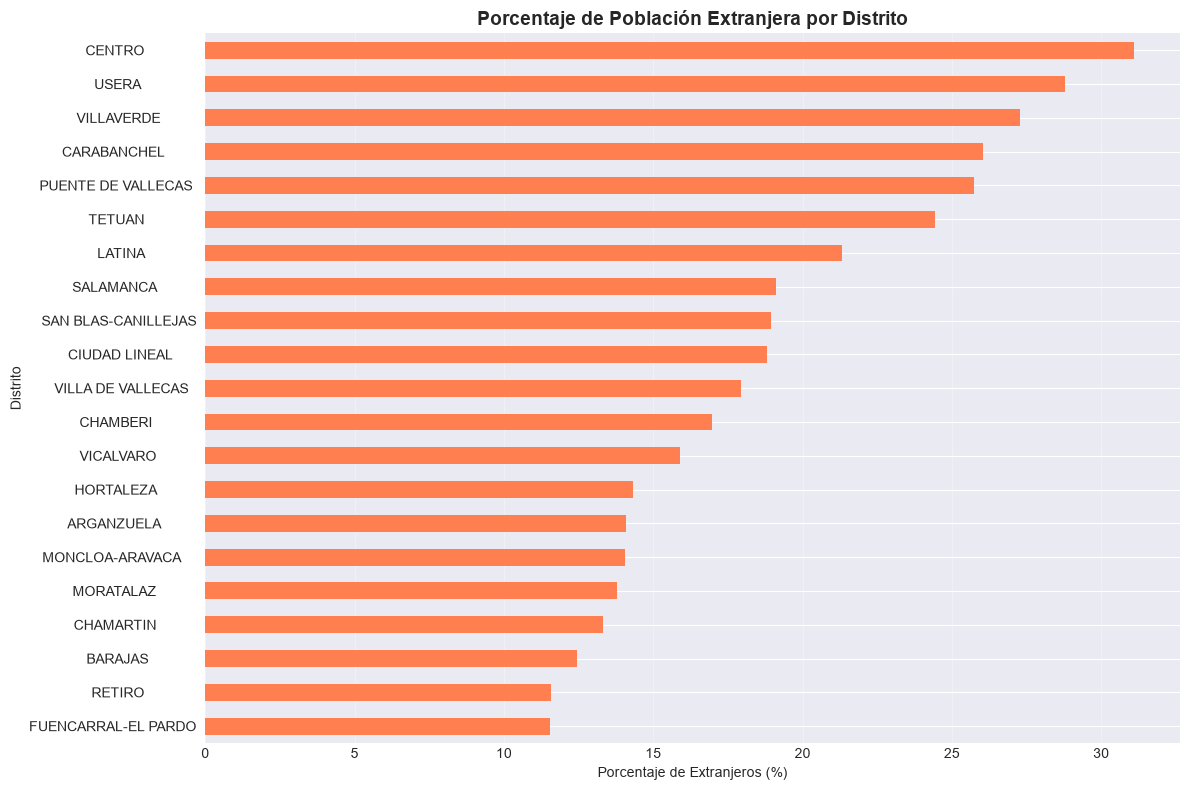

In [11]:
# Gráfico 3: Porcentaje extranjeros por distrito
fig, ax = plt.subplots(figsize=(12, 8))
df_ext_sorted = df_ext.sort_values('PCT_EXTRANJEROS', ascending=True)
df_ext_sorted['PCT_EXTRANJEROS'].plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Porcentaje de Extranjeros (%)')
ax.set_ylabel('Distrito')
ax.set_title('Porcentaje de Población Extranjera por Distrito', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
# INDICADORES RENTA

### Validaciones básicas

In [13]:
# Cargar renta limpia
df_renta = pd.read_parquet(PROCESSED_PATHS['cleaned_renta'])

print(f"Renta limpia cargada: {len(df_renta):,} filas × {df_renta.shape[1]} columnas\n")

# Validaciones
nulos = df_renta.isnull().sum().sum()
duplicados = df_renta.duplicated().sum()
tamano = df_renta.memory_usage(deep=True).sum() / 1e6

print(f"- Nulos totales: {nulos}")
print(f"- Duplicados: {duplicados}")
print(f"- Tamaño: {tamano:.2f} MB")

# Mostrar estructura
print("\n Estructura:")
df_renta.head()

Renta limpia cargada: 630 filas × 4 columnas

- Nulos totales: 0
- Duplicados: 0
- Tamaño: 0.06 MB

 Estructura:


,Distritos,Indicadores de renta media,Periodo,Total
0,2807901 Madrid distrito 01,Media de la renta por unidad de consumo,2022,28.44
1,2807901 Madrid distrito 01,Media de la renta por unidad de consumo,2023,29.93
2,2807901 Madrid distrito 01,Mediana de la renta por unidad de consumo,2022,22.56
3,2807901 Madrid distrito 01,Mediana de la renta por unidad de consumo,2023,23.71
4,2807901 Madrid distrito 01,Renta bruta media por hogar,2022,53.90


### Cobertura

In [15]:
distritos = df_renta['Distritos'].nunique()
indicadores = df_renta['Indicadores de renta media'].nunique()
anios = sorted(df_renta['Periodo'].unique())

print(f" Distritos: {distritos}")
print(f" Indicadores: {indicadores}")
print(f" Años: {anios[0]} - {anios[-1]} ({len(anios)} años)")
print(f"\n Matriz esperada: {distritos} × {indicadores} × {len(anios)} = {distritos*indicadores*len(anios):,}")
print(f" Matriz real: {len(df_renta):,}")

# Indicadores
print(f"\n📊 Indicadores representados:")
for ind in df_renta['Indicadores de renta media'].unique():
    print(f"  • {ind}")

 Distritos: 21
 Indicadores: 6
 Años: 2022 - 2026 (5 años)

 Matriz esperada: 21 × 6 × 5 = 630
 Matriz real: 630

📊 Indicadores representados:
  • Media de la renta por unidad de consumo
  • Mediana de la renta por unidad de consumo
  • Renta bruta media por hogar
  • Renta bruta media por persona
  • Renta neta media por hogar
  • Renta neta media por persona


### Análisis de valores

In [16]:
print(" Estadísticas de Renta (Total en miles €):\n")
print(df_renta['Total'].describe())

# Renta por distrito (año más reciente)
anio_max = df_renta['Periodo'].max()
df_renta_2026 = df_renta[df_renta['Periodo'] == anio_max].copy()

# Tomar solo un indicador para comparar
indicador = df_renta_2026['Indicadores de renta media'].iloc[0]
renta_distritos = df_renta_2026[df_renta_2026['Indicadores de renta media'] == indicador].sort_values('Total', ascending=False)

print(f"\n Renta Media Hogar {anio_max} por Distrito (€):")
print(renta_distritos[['Distritos', 'Total']].head(15))

 Estadísticas de Renta (Total en miles €):

count   630.00
mean     34.99
std      19.13
min      11.28
25%      21.04
50%      29.21
75%      42.69
max     101.00
Name: Total, dtype: float64

 Renta Media Hogar 2026 por Distrito (€):
                      Distritos  Total
528  2807905 Madrid distrito 05  43.93
522  2807904 Madrid distrito 04  42.98
540  2807907 Madrid distrito 07  41.43
516  2807903 Madrid distrito 03  39.15
552  2807909 Madrid distrito 09  38.70
546  2807908 Madrid distrito 08  33.15
624  2807921 Madrid distrito 21  32.76
594  2807916 Madrid distrito 16  32.20
510  2807902 Madrid distrito 02  32.13
504  2807901 Madrid distrito 01  29.93
534  2807906 Madrid distrito 06  28.22
588  2807915 Madrid distrito 15  26.99
582  2807914 Madrid distrito 14  24.98
618  2807920 Madrid distrito 20  23.79
606  2807918 Madrid distrito 18  22.44


### Gráficos de renta

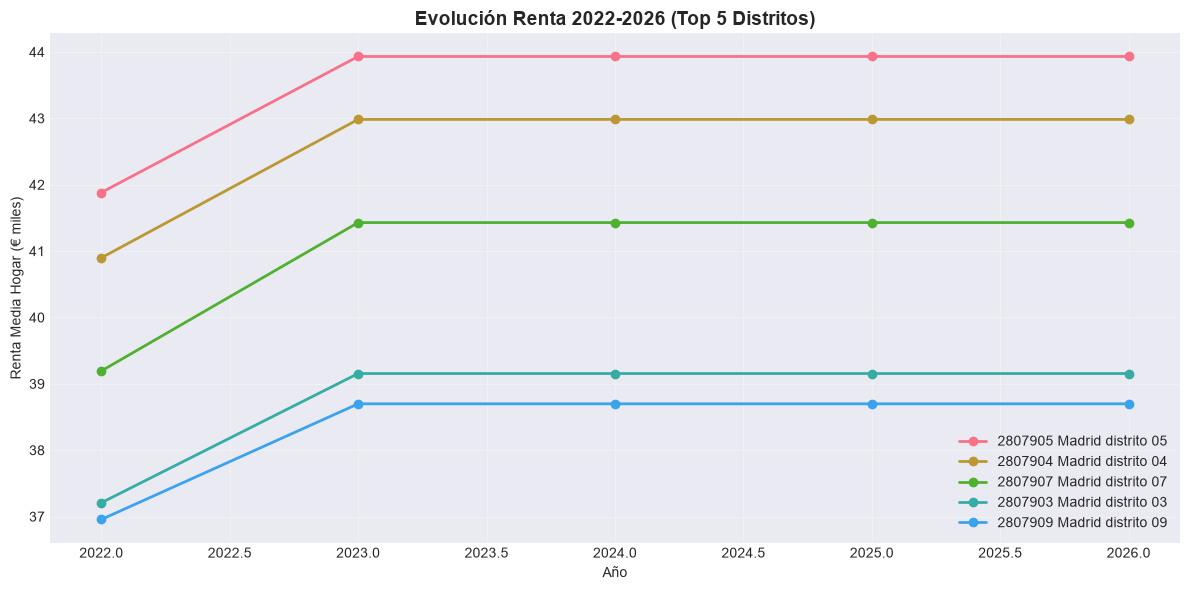

In [17]:
# Gráfico: Evolución temporal de renta
fig, ax = plt.subplots(figsize=(12, 6))

# Seleccionar un indicador y algunos distritos
indicador_sel = df_renta['Indicadores de renta media'].iloc[0]
df_renta_sel = df_renta[df_renta['Indicadores de renta media'] == indicador_sel]

# Distritos con mayor y menor renta
distritos_top = renta_distritos['Distritos'].head(5).tolist()

for distrito in distritos_top:
    data = df_renta_sel[df_renta_sel['Distritos'] == distrito].sort_values('Periodo')
    ax.plot(data['Periodo'], data['Total'], marker='o', label=distrito, linewidth=2)

ax.set_xlabel('Año')
ax.set_ylabel('Renta Media Hogar (€ miles)')
ax.set_title(f'Evolución Renta 2022-2026 (Top 5 Distritos)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

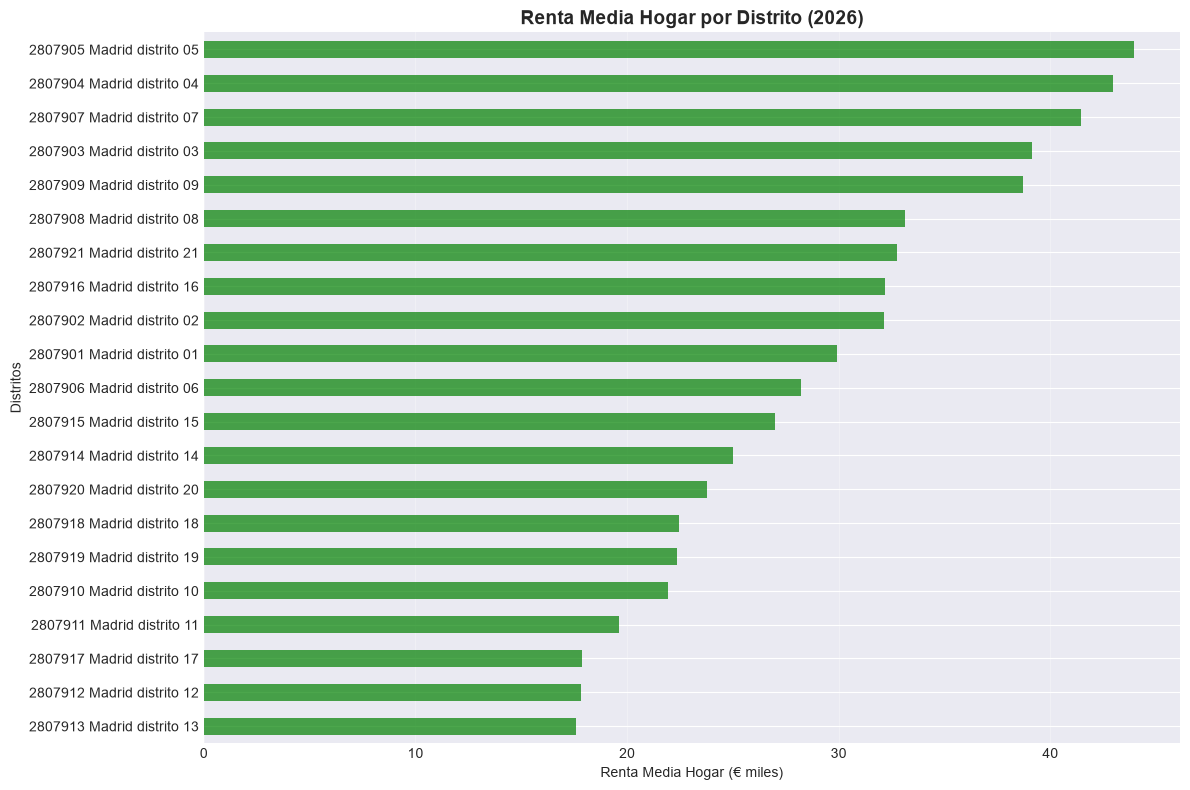

In [19]:
# Gráfico: Renta por distrito (año 2026)
fig, ax = plt.subplots(figsize=(12, 8))
renta_plot = renta_distritos.sort_values('Total', ascending=True)
renta_plot.set_index('Distritos')['Total'].plot(kind='barh', ax=ax, color='green', alpha=0.7)
ax.set_xlabel('Renta Media Hogar (€ miles)')
ax.set_title(f'Renta Media Hogar por Distrito ({anio_max})', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
# PRECIOS HISTÓRICOS

### Validaciones básicas

In [21]:
# Cargar precios limpios
df_precios = pd.read_parquet(PROCESSED_PATHS['cleaned_precios'])

print(f"Precios limpios cargados: {len(df_precios):,} filas × {df_precios.shape[1]} columnas\n")

# Validaciones
nulos = df_precios.isnull().sum().sum()
duplicados = df_precios.duplicated().sum()
tamanio = df_precios.memory_usage(deep=True).sum() / 1e6

print(f"- Nulos totales: {nulos}")
print(f"- Duplicados: {duplicados}")
print(f"- Tamaño: {tamanio:.2f} MB")

# Mostrar estructura
print("\n Estructura:")
df_precios.head()

Precios limpios cargados: 294 filas × 6 columnas

- Nulos totales: 63
- Duplicados: 0
- Tamaño: 0.02 MB

 Estructura:


,distrito,año,precio_m2_eur,precio_anterior,cambio_absoluto,pct_cambio_yoy
0,Arganzuela,2013,2850,NaN,NaN,NaN
1,Arganzuela,2014,2980,2850.00,130.00,4.56
2,Arganzuela,2015,3150,2980.00,170.00,5.70
3,Arganzuela,2016,3450,3150.00,300.00,9.52
4,Arganzuela,2017,3780,3450.00,330.00,9.57


### Cobertura

In [22]:
distritos = df_precios['distrito'].nunique()
anios = sorted(df_precios['año'].unique())

print(f" Distritos: {distritos}")
print(f" Años: {anios[0]} - {anios[-1]} ({len(anios)} años)")
print(f"\n Matriz esperada: {distritos} × {len(anios)} = {distritos*len(anios):,}")
print(f" Matriz real: {len(df_precios):,}")

# Registros por distrito
print(f"\n Registros por distrito: {df_precios.groupby('distrito').size().unique()[0]}")

 Distritos: 21
 Años: 2013 - 2026 (14 años)

 Matriz esperada: 21 × 14 = 294
 Matriz real: 294

 Registros por distrito: 14


### Análisis de precios

In [23]:
print(" Estadísticas de Precios (€/m²):\n")
print(df_precios['precio_m2_eur'].describe())

# Precios 2026
anio_max_precios = df_precios['año'].max()
precios_2026 = df_precios[df_precios['año'] == anio_max_precios].sort_values('precio_m2_eur', ascending=False)

print(f"\n Precios {anio_max_precios} por Distrito (€/m²):")
print(precios_2026[['distrito', 'precio_m2_eur']].reset_index(drop=True))

# Cambios
cambios = df_precios['pct_cambio_yoy'].dropna()
print(f"\n Cambios Año a Año (%):\n")
print(f"  Media: {cambios.mean():.2f}%")
print(f"  Mediana: {cambios.median():.2f}%")
print(f"  Min: {cambios.min():.2f}%")
print(f"  Max: {cambios.max():.2f}%")

 Estadísticas de Precios (€/m²):

count    294.00
mean    4378.05
std     1560.03
min     1550.00
25%     3057.50
50%     4380.00
75%     5372.50
max     8320.00
Name: precio_m2_eur, dtype: float64

 Precios 2026 por Distrito (€/m²):
              distrito  precio_m2_eur
0               Centro           8320
1             Chamberí           7950
2               Retiro           7610
3            Chamartín           7520
4            Salamanca           6769
5               Tetuán           6350
6           Arganzuela           6250
7              Moncloa           6050
8          Carabanchel           5850
9            Hortaleza           5850
10              Latina           5750
11       Ciudad Lineal           5750
12          Fuencarral           5350
13           Moratalaz           5250
14            San Blas           5150
15             Barajas           5050
16               Usera           5050
17  Puente de Vallecas           4950
18   Villa de Vallecas           4850
19    

### Gráficos de precios

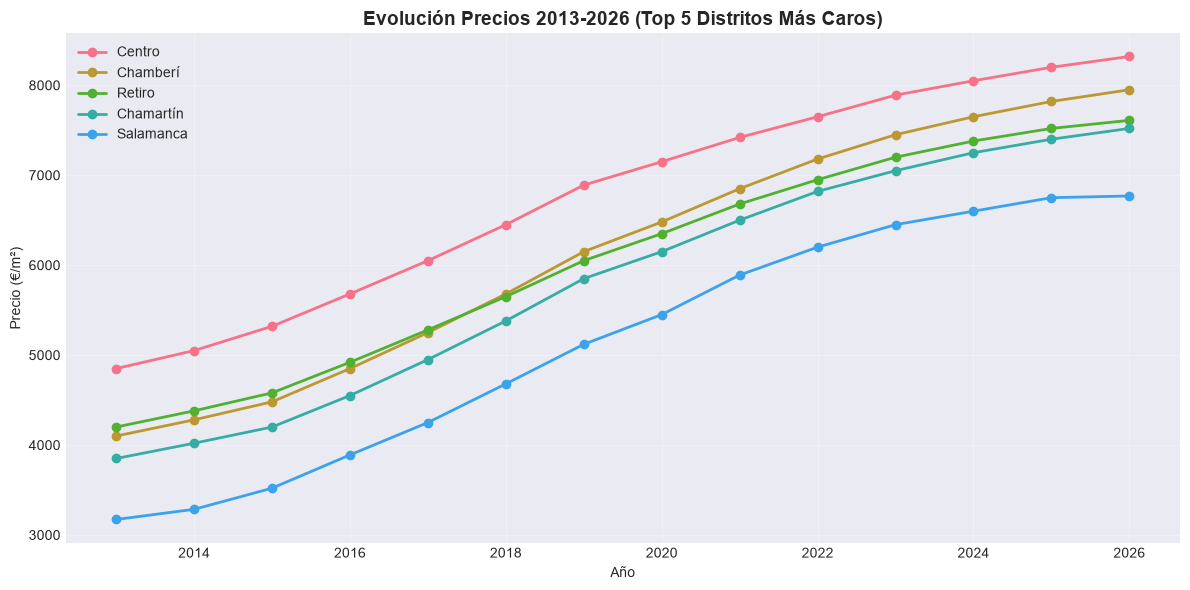

In [24]:
# Gráfico: Evolución precios por distrito (top 5)
fig, ax = plt.subplots(figsize=(12, 6))

distritos_top = precios_2026['distrito'].head(5).tolist()

for distrito in distritos_top:
    data = df_precios[df_precios['distrito'] == distrito].sort_values('año')
    ax.plot(data['año'], data['precio_m2_eur'], marker='o', label=distrito, linewidth=2)

ax.set_xlabel('Año')
ax.set_ylabel('Precio (€/m²)')
ax.set_title('Evolución Precios 2013-2026 (Top 5 Distritos Más Caros)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

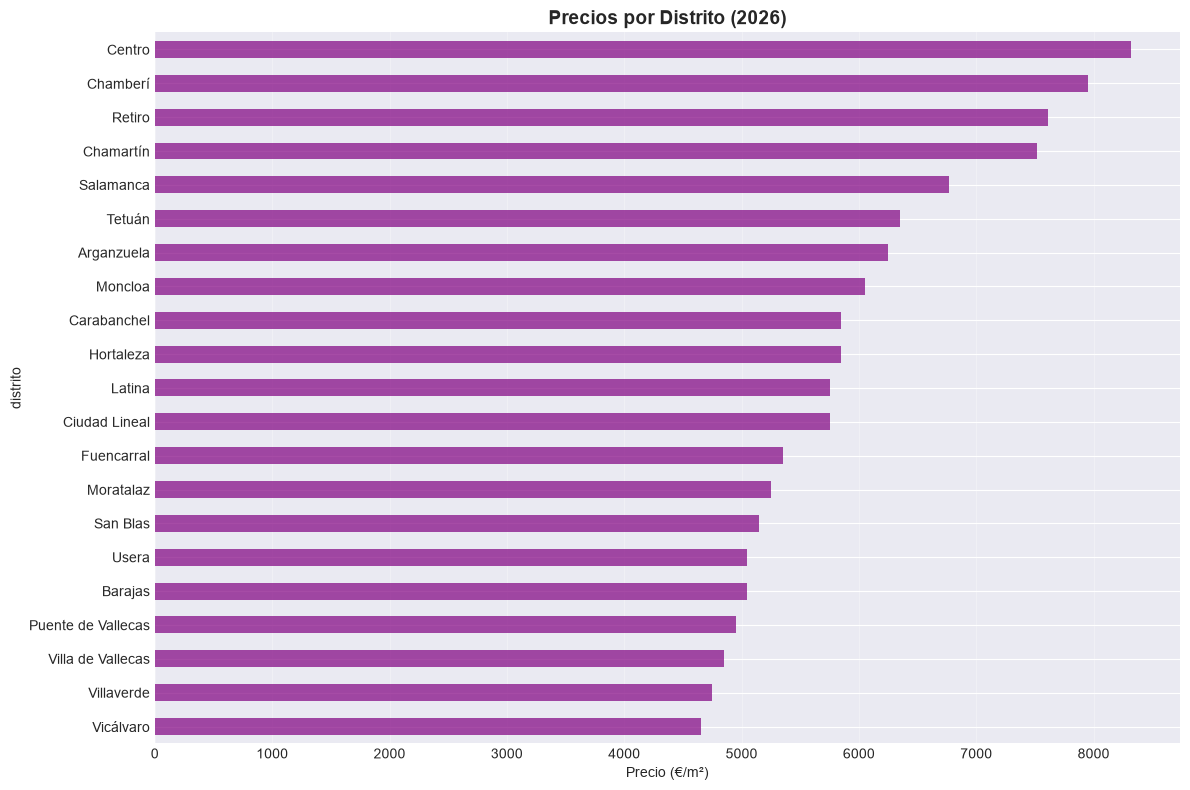

In [26]:
# Gráfico: Precios 2026 por distrito
fig, ax = plt.subplots(figsize=(12, 8))
precios_plot = precios_2026.sort_values('precio_m2_eur', ascending=True)
precios_plot.set_index('distrito')['precio_m2_eur'].plot(kind='barh', ax=ax, color='purple', alpha=0.7)
ax.set_xlabel('Precio (€/m²)')
ax.set_title(f'Precios por Distrito ({anio_max_precios})', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
# BARRIOS

### Validaciones básicas

In [ ]:
# Cargar barrios limpios
df_barrios = pd.read_parquet(PROCESSED_PATHS['cleaned_barrios'])

print(f"Barrios limpios cargados: {len(df_barrios):,} filas × {df_barrios.shape[1]} columnas\n")

# Validaciones
nulos = df_barrios.isnull().sum().sum()
duplicados = df_barrios.duplicated().sum()
tamanio = df_barrios.memory_usage(deep=True).sum() / 1e6

print(f"- Nulos totales: {nulos}")
print(f"- Duplicados: {duplicados}")
print(f"- Tamaño: {tamanio:.2f} MB")

# Mostrar estructura
print("\n Estructura:")
df_barrios.head()

Barrios limpios cargados: 131 filas × 5 columnas

- Nulos totales: 0
- Duplicados: 0
- Tamaño: 0.01 MB

 Estructura:


,CODDIS,NOMDIS,COD_BAR,NOMBRE,Area
0,1,Centro,11,Palacio,1469905.93
1,1,Centro,12,Embajadores,1033724.49
2,1,Centro,13,Cortes,591874.24
3,1,Centro,14,Justicia,739413.49
4,1,Centro,15,Universidad,948026.38


### Cobertura geográfica

In [29]:
distritos = df_barrios['CODDIS'].nunique()
barrios = df_barrios['NOMBRE'].nunique()
area_total = df_barrios['Area'].sum()

print(f" Distritos: {distritos}")
print(f" Barrios: {barrios}")
print(f" Área total Madrid: {area_total:,.0f} m² = {area_total/1e6:.1f} km²")

# Barrios por distrito
print(f"\n Barrios por distrito:")
barrios_x_distrito = df_barrios.groupby('NOMDIS').size().sort_values(ascending=False)
for distrito, count in barrios_x_distrito.items():
    print(f"  {distrito:30s} {count:2d} barrios")

 Distritos: 21
 Barrios: 131
 Área total Madrid: 604,014,551 m² = 604.0 km²

 Barrios por distrito:
  Ciudad Lineal                   9 barrios
  Fuencarral - El Pardo           8 barrios
  San Blas - Canillejas           8 barrios
  Carabanchel                     7 barrios
  Arganzuela                      7 barrios
  Usera                           7 barrios
  Latina                          7 barrios
  Moncloa - Aravaca               7 barrios
  Centro                          6 barrios
  Puente de Vallecas              6 barrios
  Chamartín                       6 barrios
  Hortaleza                       6 barrios
  Chamberí                        6 barrios
  Tetuán                          6 barrios
  Moratalaz                       6 barrios
  Salamanca                       6 barrios
  Retiro                          6 barrios
  Barajas                         5 barrios
  Villaverde                      5 barrios
  Vicálvaro                       4 barrios
  Villa de Vallecas 

### Análisis de área

In [30]:
print(" Estadísticas de Área (m²):\n")
print(df_barrios['Area'].describe())

# Barrios más grandes y pequeños
print(f"\n Barrios más GRANDES:")
print(df_barrios.nlargest(10, 'Area')[['NOMDIS', 'NOMBRE', 'Area']].reset_index(drop=True))

print(f"\n Barrios más PEQUEÑOS:")
print(df_barrios.nsmallest(10, 'Area')[['NOMDIS', 'NOMBRE', 'Area']].reset_index(drop=True))

 Estadísticas de Área (m²):

count         131.00
mean      4610798.10
std      17120417.09
min        248882.86
25%        816357.93
50%       1363211.90
75%       2538812.51
max     187583248.11
Name: Area, dtype: float64

 Barrios más GRANDES:
                  NOMDIS                        NOMBRE         Area
0  Fuencarral - El Pardo                      El Pardo 187583248.11
1      Villa de Vallecas   Casco Histórico de Vallecas  42989207.05
2                Barajas                    Aeropuerto  29664730.87
3  Fuencarral - El Pardo                     El Goloso  26493113.03
4              Vicálvaro  Casco Histórico de Vicálvaro  21075999.61
5      Moncloa - Aravaca                 Casa de Campo  17476000.25
6              Hortaleza                  Valdefuentes  17023150.03
7      Moncloa - Aravaca          Ciudad Universitaria  14250852.89
8              Vicálvaro                  El Cañaveral  10567690.00
9  San Blas - Canillejas                         Rosas   9293703.73

 Bar

### Gráficos Barrios

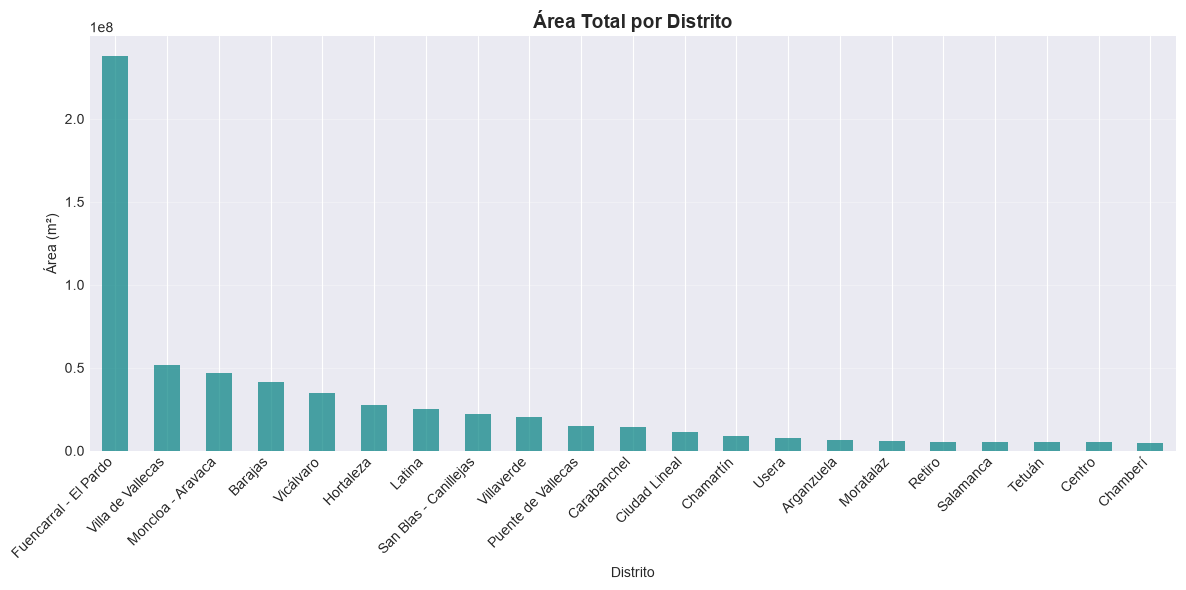

In [31]:
# Gráfico: Área por distrito
fig, ax = plt.subplots(figsize=(12, 6))
area_distrito = df_barrios.groupby('NOMDIS')['Area'].sum().sort_values(ascending=False)
area_distrito.plot(kind='bar', ax=ax, color='teal', alpha=0.7)
ax.set_ylabel('Área (m²)')
ax.set_xlabel('Distrito')
ax.set_title('Área Total por Distrito', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

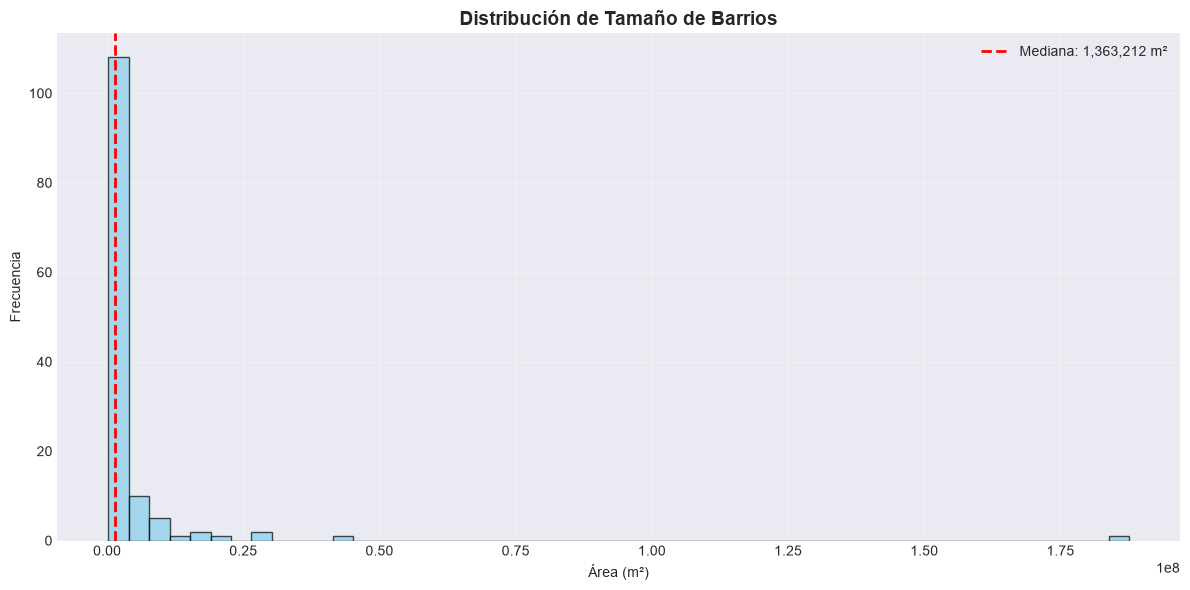

In [32]:
# Gráfico: Distribución de tamaños de barrios
fig, ax = plt.subplots(figsize=(12, 6))
df_barrios['Area'].hist(bins=50, ax=ax, color='skyblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Área (m²)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de Tamaño de Barrios', fontsize=14, fontweight='bold')
ax.axvline(df_barrios['Area'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {df_barrios["Area"].median():,.0f} m²')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()